1️⃣ DATA COLLECTION
Step 1: Import Libraries

In [1]:
!pip install xgboost

In [2]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Imbalance
from imblearn.over_sampling import SMOTE

# Save model
import pickle

Step 2: Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\yashv\Downloads\cover_type (1).csv")

In [4]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


Check Missing Values

In [6]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

Check Duplicates

In [7]:
df.duplicated().sum()
df = df.drop_duplicates()
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29


Check Target Distribution

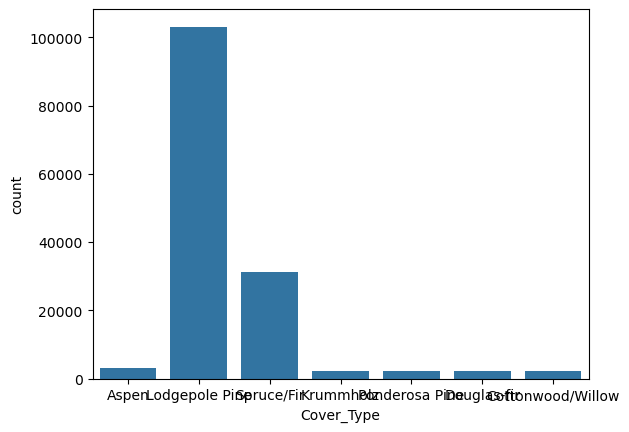

In [8]:
df['Cover_Type'].value_counts()
sns.countplot(x='Cover_Type', data=df)
plt.show()

3️⃣ DATA CLEANING & TRANSFORMATION
Handling Missing Values

If numeric:

In [9]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Cover_Type' in numeric_columns:
    numeric_columns.remove('Cover_Type')

numeric_columns

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points',
 'Wilderness_Area',
 'Soil_Type']

In [10]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

In [11]:
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X[numeric_columns] = imputer.fit_transform(X[numeric_columns])

In [13]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

In [14]:
df['Cover_Type'].dtype

dtype('O')

In [15]:
df['Cover_Type_Name'] = df['Cover_Type'].map(cover_type_map)

NameError: name 'cover_type_map' is not defined

In [16]:
df.drop('Cover_Type_Name', axis=1, inplace=True)

KeyError: "['Cover_Type_Name'] not found in axis"

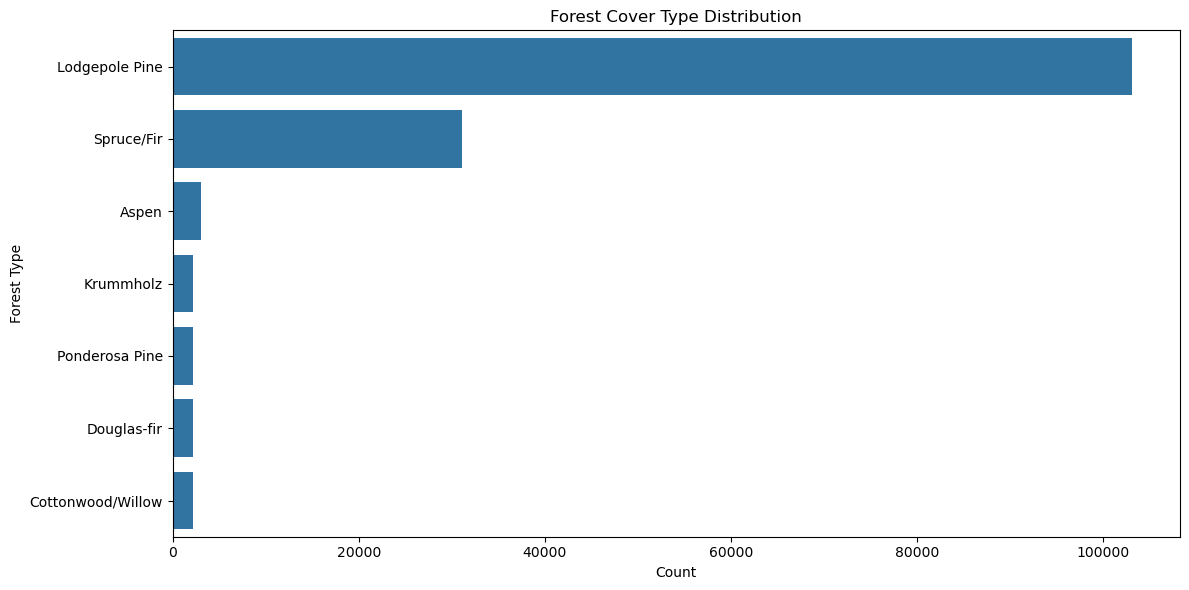

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='Cover_Type',
    data=df,
    order=df['Cover_Type'].value_counts().index
)

plt.title("Forest Cover Type Distribution")
plt.xlabel("Count")
plt.ylabel("Forest Type")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df['Cover_Type'] = le_target.fit_transform(df['Cover_Type'])

In [19]:
import os

os.makedirs("models", exist_ok=True)

In [20]:
import pickle

pickle.dump(le_target, open("models/target_encoder.pkl", "wb"))

In [21]:

# create folder safely
os.makedirs("models", exist_ok=True)

# save encoder
with open("models/target_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

In [22]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

In [23]:
imputer = SimpleImputer(strategy="median")
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [24]:
df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)

C:\Users\yashv\AppData\Local\Temp\ipykernel_10052\1080442724.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Soil_Type'].fillna(df['Soil_Type'].mode()[0], inplace=True)


In [25]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numeric_columns] < (Q1 - 1.5 * IQR)) |
          (df[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [26]:
for col in numeric_columns:
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])


4️⃣ FEATURE ENGINEERING

Encode Categorical Variables

In [27]:
le = LabelEncoder()
df['Wilderness_Area'] = le.fit_transform(df['Wilderness_Area'])
df['Soil_Type'] = le.fit_transform(df['Soil_Type'])

C:\Users\yashv\AppData\Local\Temp\ipykernel_10052\1406660118.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Wilderness_Area'] = le.fit_transform(df['Wilderness_Area'])
C:\Users\yashv\AppData\Local\Temp\ipykernel_10052\1406660118.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Soil_Type'] = le.fit_transform(df['Soil_Type'])


In [28]:
pickle.dump(le, open("models/encoder.pkl", "wb"))

5️⃣ EDA (Exploratory Data Analysis)

Histogram

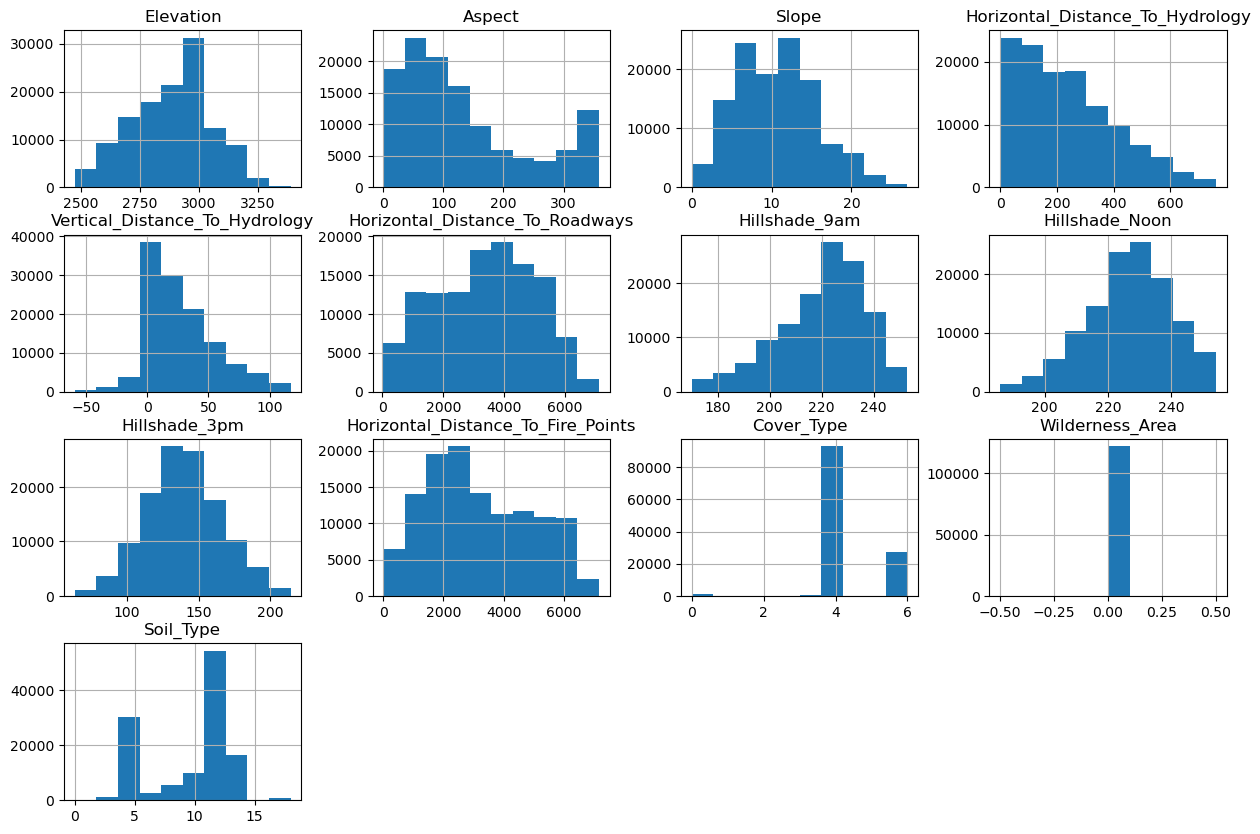

In [29]:
df.hist(figsize=(15,10))
plt.show()

Correlation Heatmap

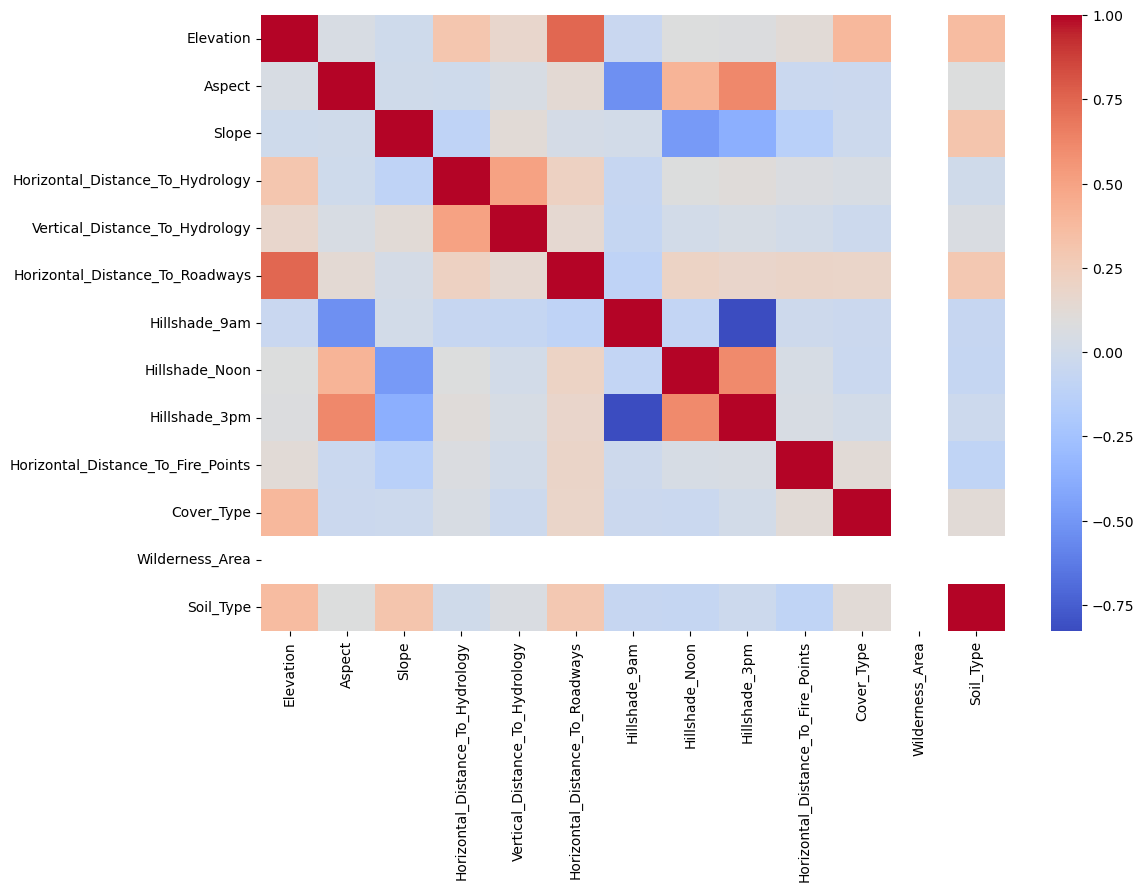

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

6️⃣ HANDLE CLASS IMBALANCE

In [31]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

7️⃣ FEATURE SELECTION

Using Random Forest Importance

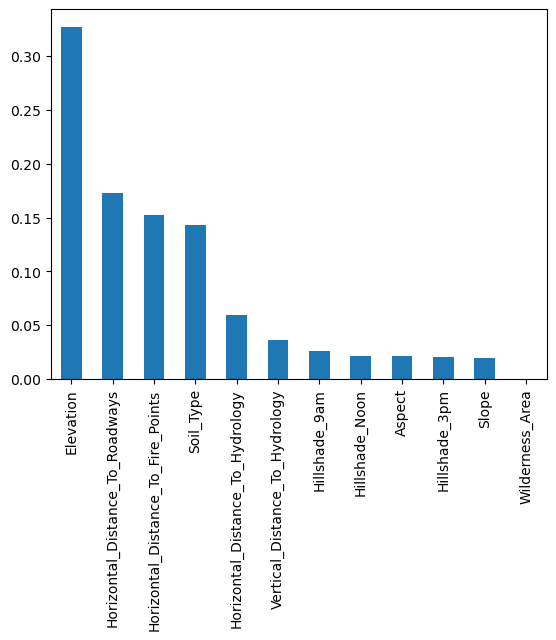

In [32]:
rf = RandomForestClassifier()
rf.fit(X_resampled, y_resampled)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.show()

8️⃣ MODEL BUILDING
Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

5 Models Training
1️⃣ Random Forest

In [34]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

2️⃣ Decision Tree

In [35]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

3️⃣ Logistic Regression

In [36]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

C:\Users\yashv\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4️⃣ KNN

In [37]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

5️⃣ XGBoost

In [38]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 3 4 6]

Model Evaluation

In [ ]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

In [ ]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True)
plt.show()

Hyperparameter Tuning

Example for Random Forest:

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100,200],
    'max_depth': [10,20,None],
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid=params,
                    cv=3)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

9️⃣ SAVE FINAL MODEL

In [ ]:
pickle.dump(best_model, open("models/best_model.pkl", "wb"))

🔟 STREAMLIT APP

In [ ]:
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("models/best_model.pkl", "rb"))

st.title("Forest Cover Type Prediction")

elevation = st.number_input("Elevation")
slope = st.number_input("Slope")

if st.button("Predict"):
    input_data = np.array([[elevation, slope, ...]])
    prediction = model.predict(input_data)
    st.success(f"Predicted Cover Type: {prediction[0]}")